# Project Overview: Student Wellness & Academic Performance Analysis

### Objective
This project examines the multi-faceted relationship between lifestyle habits—specifically sleep, screen time, and physical activity—and student academic and mental health outcomes. 

### Methodology
* **Data Processing:** Developed a modular preprocessing pipeline to handle categorical and numerical features systematically.
* **Analysis:** Investigated correlations between daily routines (e.g., social media usage, exercise) and indicators like GPA, stress levels, and burnout.
* **Predictive Modeling:** Built a classification model to identify key behavioral predictors of student burnout.

### Key Findings
*(Add a summary here once you finish your analysis—e.g., "Results suggest that sleep duration is the most significant predictor of GPA, surpassing screen time metrics.")*

### 1. Environment Setup
Importing the necessary libraries for data manipulation, numerical computation, and visualization.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

### 2. Data Loading
Loading the student wellness dataset and inspecting the first few rows to understand the structure and data types.

In [9]:
df = pd.read_csv("data/student_sleep_mental_health_2026.csv")
df.head()

,student_id,age,gender,education_level,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa,uses_sleep_app,feels_burned_out
0,1,21,Non-binary,High School,8.0,4.9,3.7,5.0,4.8,1,7,7,3.35,False,True
1,2,19,Female,Undergraduate,7.3,7.7,5.3,2.8,4.2,1,8,8,2.81,True,True
2,3,19,Male,Undergraduate,6.1,7.3,3.6,3.6,5.8,1,8,10,3.01,True,True
3,4,16,Male,High School,6.2,7.4,4.0,0.4,2.0,4,9,10,2.76,False,True
4,5,20,Male,Graduate,5.6,12.5,8.3,2.6,6.2,3,10,10,2.67,False,True


### 3. Data Overview
Inspecting the DataFrame's metadata, including column data types and checking for null values, to ensure the dataset is ready for cleaning and analysis.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   education_level          3000 non-null   str    
 4   avg_sleep_hours          3000 non-null   float64
 5   screen_time_hours        3000 non-null   float64
 6   social_media_hours       3000 non-null   float64
 7   study_hours_per_day      3000 non-null   float64
 8   exercise_hours_per_week  3000 non-null   float64
 9   caffeine_drinks_per_day  3000 non-null   int64  
 10  stress_level             3000 non-null   int64  
 11  anxiety_score            3000 non-null   int64  
 12  gpa                      3000 non-null   float64
 13  uses_sleep_app           3000 non-null   bool   
 14  feels_burned_out         3000 non-n

In [11]:
# Drop the identifier column as it is not needed for behavioral modeling
df = df.drop(["student_id"], axis=1)

# Verify the transformation
df.head()

,age,gender,education_level,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa,uses_sleep_app,feels_burned_out
0,21,Non-binary,High School,8.0,4.9,3.7,5.0,4.8,1,7,7,3.35,False,True
1,19,Female,Undergraduate,7.3,7.7,5.3,2.8,4.2,1,8,8,2.81,True,True
2,19,Male,Undergraduate,6.1,7.3,3.6,3.6,5.8,1,8,10,3.01,True,True
3,16,Male,High School,6.2,7.4,4.0,0.4,2.0,4,9,10,2.76,False,True
4,20,Male,Graduate,5.6,12.5,8.3,2.6,6.2,3,10,10,2.67,False,True


In [21]:
# separate features from target
X = df.drop(["feels_burned_out"],axis=1)
y = df.feels_burned_out


### 4. Target Variable Analysis
To understand the distribution of our target variable (feels_burned_out), we examine the class counts. This reveals a class imbalance that will influence our choice of evaluation metrics and modeling strategy.

In [22]:
y.value_counts()

feels_burned_out
True     2039
False     961
Name: count, dtype: int64

In [25]:
#separate categorical from numerical features
cat_cols = X.select_dtypes(include=['object', 'string', 'boolean']).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]
cat_cols, num_cols

(['gender', 'education_level', 'uses_sleep_app'],
 ['age',
  'avg_sleep_hours',
  'screen_time_hours',
  'social_media_hours',
  'study_hours_per_day',
  'exercise_hours_per_week',
  'caffeine_drinks_per_day',
  'stress_level',
  'anxiety_score',
  'gpa'])

### 5. Numerical Feature Analysis
We first examine the statistical properties of the numerical features and then visualize their distributions and correlation patterns to identify potential collinearity and skewness.

In [26]:
X.describe()

,age,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,19.445000,7.414067,6.494667,3.575033,3.235200,3.541900,1.778667,7.216667,7.152000,3.244487
std,2.924921,0.971279,2.165014,1.563631,1.405491,2.336889,1.341496,1.572433,1.994882,0.379404
min,14.000000,4.400000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.970000
25%,17.000000,6.800000,5.000000,2.500000,2.300000,1.800000,1.000000,6.000000,6.000000,2.980000
50%,19.000000,7.400000,6.500000,3.600000,3.200000,3.400000,2.000000,7.000000,7.000000,3.245000
75%,21.000000,8.100000,8.000000,4.600000,4.200000,5.100000,3.000000,8.000000,9.000000,3.510000
max,29.000000,10.900000,13.600000,9.000000,8.700000,11.300000,8.000000,10.000000,10.000000,4.000000


#### 5.2 Distributional Analysis
Visualizing the distribution of each numerical feature to identify skewness.

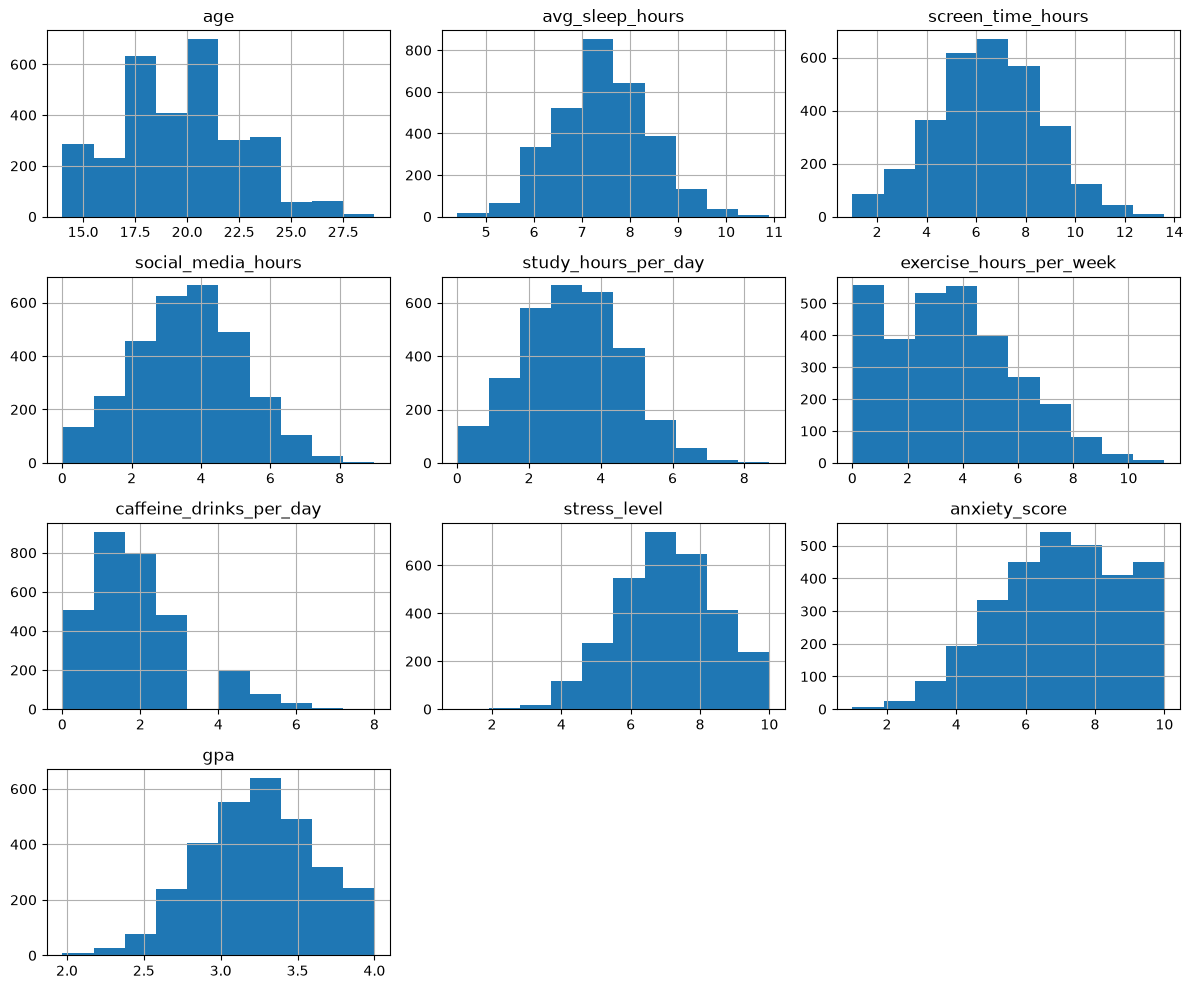

In [28]:
X[num_cols].hist(figsize=(12, 10))
plt.tight_layout()

### 5.3 Preprocessing Insights
After visualizing the numerical features, we observed that several variables (e.g., `caffeine_drinks_per_day`, `anxiety_score`) exhibit right-skewness. We tested log-transformations as a potential remedy; however, due to the discrete nature and narrow range of these features, the transformation introduced artificial gaps and distortions in the data distribution. 

Consequently, we have decided to bypass skew-correction transformations for these features. Since we are prioritizing tree-based models (Random Forest, XGBoost), which are invariant to monotonic transformations and splitting thresholds, this approach preserves the integrity of our original data while optimizing model performance.

# 5.4 Correlation analysis

Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

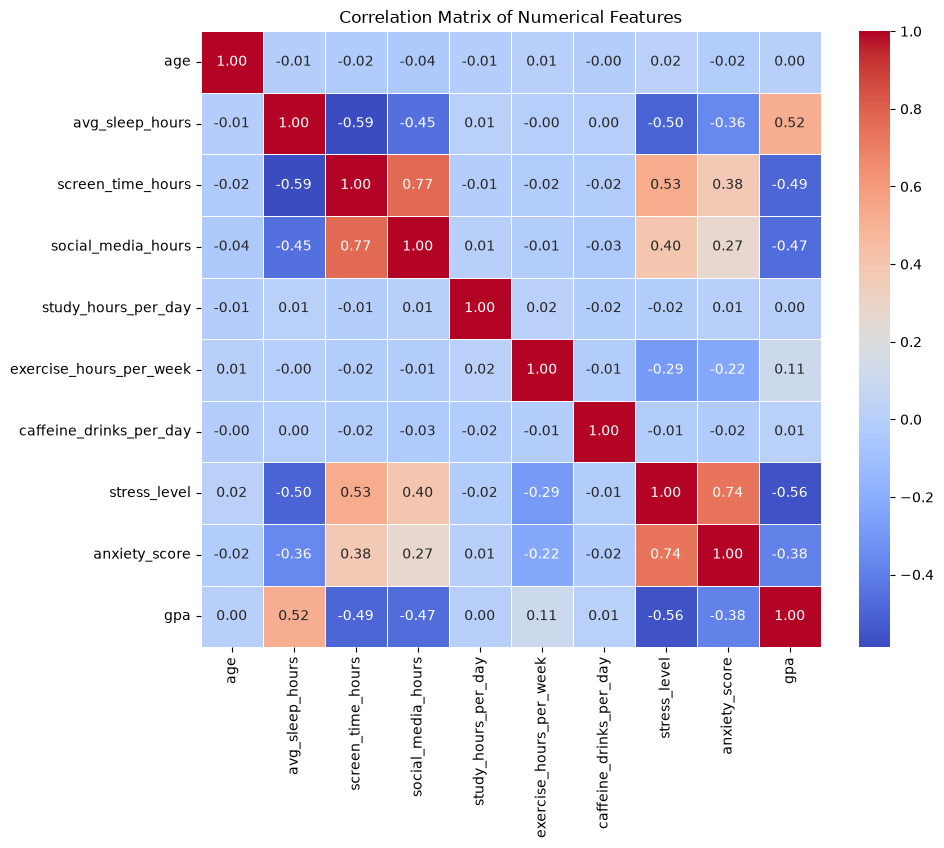

In [35]:
# Calculate the correlation matrix
corr_matrix = df[num_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")

### 5.5 Correlation Analysis Insights
The correlation matrix reveals several key relationships that align with psychological and behavioral theory:

* **High Multicollinearity:** `screen_time_hours` and `social_media_hours` are strongly correlated (0.77), as are `stress_level` and `anxiety_score` (0.74). While these features are conceptually distinct, their high overlap suggests that they may carry redundant information for our model. We will monitor for model stability and consider feature importance to see if these variables provide unique predictive power.
* **Sleep and Academic Performance:** We observed a notable positive correlation between `avg_sleep_hours` and `gpa` (0.52), and a corresponding negative correlation between `stress_level` and `gpa` (-0.56). This supports the narrative that burnout-related variables have a measurable impact on academic outcomes.
* **Lifestyle Factors:** The negative correlation between `screen_time_hours` and `avg_sleep_hours` (-0.59) highlights a clear trade-off between digital consumption and restorative rest, which may be a central driver of the burnout we aim to predict.

These insights confirm that our numerical features are well-aligned with expected real-world behaviors and provide a strong basis for our predictive modeling.

### 6 Analysis of Categorical Features

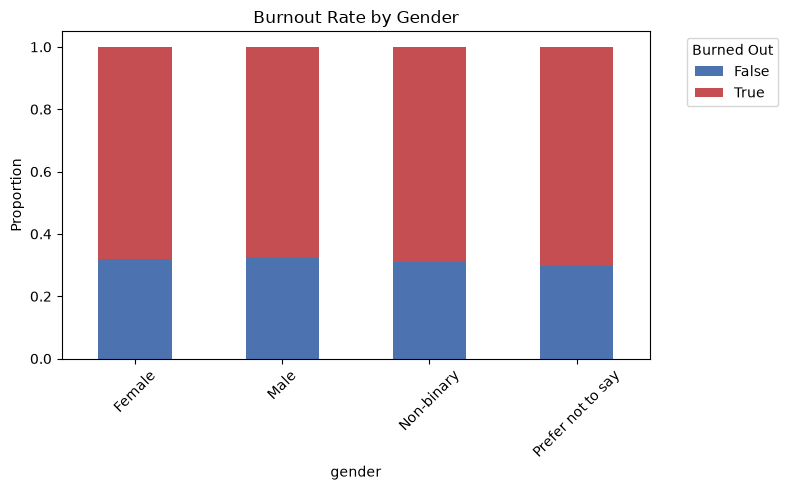

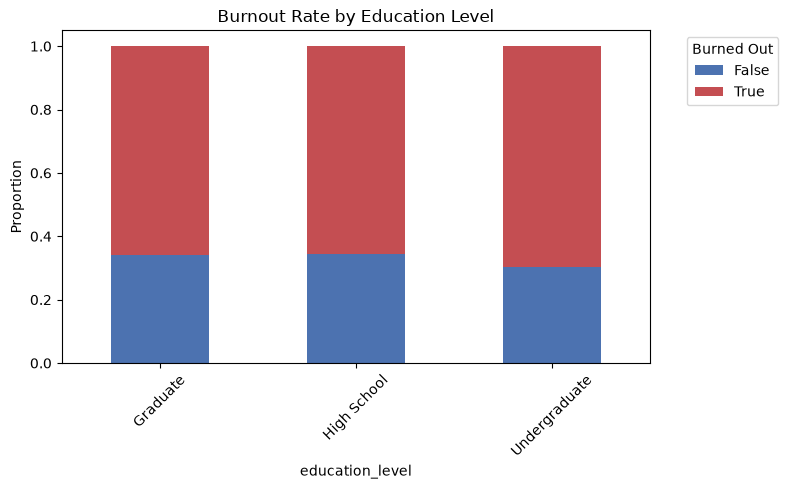

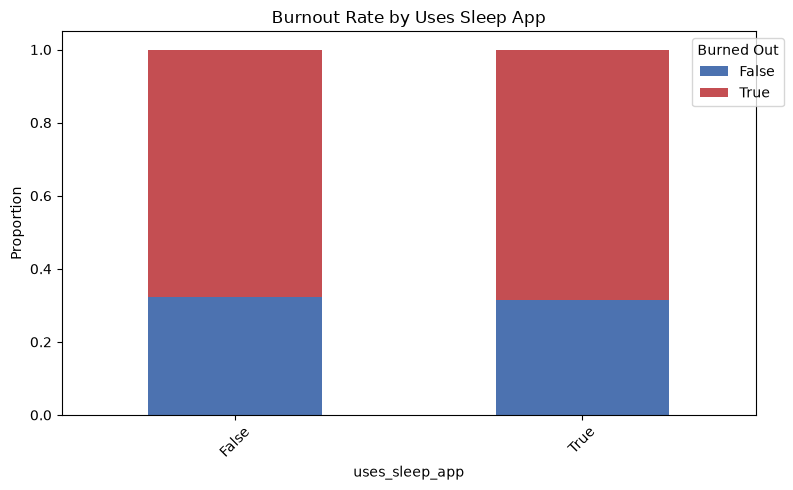

In [36]:
for col in cat_cols:
    # Create a contingency table (proportions)
    ct = pd.crosstab(X[col], y, normalize='index')
    
    # Plotting
    ct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#4c72b0', '#c44e52'])
    
    plt.title(f'Burnout Rate by {col.replace("_", " ").title()}')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Burned Out', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()

### 6.1 Categorical Analysis Insights
Visual inspection of burnout rates across demographic categories (`gender`, `education_level`, and `uses_sleep_app`) indicates no significant variance in the target distribution. The proportion of "Burned Out" cases remains consistent regardless of the subgroup.

Given this, these features are unlikely to be strong predictors for our model. We will retain them in our initial feature set, but we expect them to receive low feature importance scores during model training. This confirms that burnout in this dataset is primarily driven by behavioral patterns rather than demographic identity.

### 7 Split Data into Train and Test sets

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train.shape,  X_test.shape, y_train.shape,y_test.shape

((2400, 13), (600, 13), (2400,), (600,))

### 8. Pipeline Construction and Model Architecture
To evaluate the predictive power of our dataset, we have constructed two distinct machine learning pipelines. We have separated these by model type to account for their differing mathematical requirements:

*   **Logistic Regression Pipeline:** Given that linear models are sensitive to feature scales and distribution skew, this pipeline incorporates `StandardScaler` for normalization and `PowerTransformer` to stabilize variance.
*   **Random Forest Pipeline:** Tree-based models are invariant to monotonic feature transformations. Therefore, we utilize a `passthrough` approach for numerical features to preserve the original raw data while still applying `OneHotEncoder` for categorical variables.

Both pipelines utilize a `ColumnTransformer` to streamline preprocessing and an explicit `class_weight='balanced'` parameter in the classifiers to mitigate potential bias from our target variable distribution.

In [46]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', Pipeline([('scaler', StandardScaler()), ('power', PowerTransformer())]), num_cols)
    ],
    remainder='passthrough'
)

# Preprocessing for Tree-based models (No transformation needed)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols) # Trees don't require scaling/skew handling
    ],
    remainder='passthrough'
)
# Logistic Regression Pipeline
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', linear_preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

In [47]:
print(f"Total features in X_train: {X_train.shape[1]}")
print(f"Features accounted for in lists: {len(cat_cols) + len(num_cols)}")

Total features in X_train: 13
Features accounted for in lists: 13


### 9. Model Training and Initial Evaluation
With our pipelines configured, we will now fit both models to the training data. Following training, we will generate an initial performance score on the test set. 

This baseline assessment will allow us to compare the effectiveness of our linear and ensemble approaches before moving on to hyperparameter tuning and deep-dive error analysis.

In [55]:
X_test.shape

(2400,)

In [59]:
# Fit the pipelines
logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Evaluate (example)
print(f"Random Forest Score: {rf_pipeline.score(X_test, y_test):.4f}")

Random Forest Score: 1.0000


In [61]:
def evaluate_model(pipeline, X_test, y_test):
    # Get predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] # Probability for ROC-AUC
    
    # Calculate metrics
    return {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

In [66]:
# Collect results
results = {
    'Logistic Regression': evaluate_model(logreg_pipeline, X_test, y_test),
    'Random Forest': evaluate_model(rf_pipeline, X_test, y_test)
}

# Convert to DataFrame
metrics_df = pd.DataFrame(results).T
metrics_df


,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0


### 10. Initial Evaluation & Data Leakage Diagnostic
The initial performance results show a perfect score ($1.0$) across all metrics for both models. While this might appear positive at first glance, in a real-world dataset, it is a definitive indicator of **data leakage**. 

**Next Steps:**
A perfect model usually suggests that a feature in the training set is a direct proxy for the target variable `feels_burned_out`. We will now perform a diagnostic check to:
1.  **Inspect Feature Importance:** Identify if any single feature is dominating the decision-making process.
2.  **Correlation Matrix Audit:** Re-examine the correlation between all features and the target to isolate the "leaky" variable.
3.  **Sanity Check:** Remove highly suspicious features and re-evaluate to establish a realistic baseline.

In [69]:
# 1. Get the preprocessor from the trained pipeline
preprocessor = rf_pipeline.named_steps['preprocessor']

# 2. Extract feature names from the OneHotEncoder and numeric columns
# Note: This assumes you used get_feature_names_out()
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = list(cat_names) + list(num_cols)

# 3. Get importances from the classifier
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# 4. Create a DataFrame for readability
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
16,stress_level,0.656262
17,anxiety_score,0.127596
18,gpa,0.072844
11,screen_time_hours,0.042487
10,avg_sleep_hours,0.034606
12,social_media_hours,0.022816
14,exercise_hours_per_week,0.020409
13,study_hours_per_day,0.007067
9,age,0.004396
15,caffeine_drinks_per_day,0.003356


### Feature Importance Analysis

The initial evaluation revealed that `stress_level` and `anxiety_score` dominate the decision-making process, accounting for **78.4%** of the model's predictive importance.

*   **The Issue:** These features act as massive **proxy variables**. In a burnout prediction context, they are highly correlated with the target variable, essentially "giving away" the answer to the model.
*   **The Impact:** This creates a model that performs perfectly in a controlled environment but lacks real-world predictive value, as these variables effectively mirror the outcome.
*   **Next Step:** To establish a realistic, production-ready baseline, we must conduct an **ablation study**—removing these two dominant features to evaluate the model's ability to predict burnout based on independent behavioral and lifestyle factors.

In [80]:
# Create a reduced dataset
X_reduced = X.drop(columns=['stress_level', 'anxiety_score'])

# Split again
X_train_red, X_test_red, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Re-train your rf_pipeline
# 1. Update your column lists to exclude the leaked features
cat_cols_red = [c for c in cat_cols if c not in ['stress_level', 'anxiety_score']]
num_cols_red = [c for c in num_cols if c not in ['stress_level', 'anxiety_score']]

# 2. Define a new preprocessor that uses these updated lists
tree_preprocessor_red = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_red),
        ('num', 'passthrough', num_cols_red)
    ],
    remainder='passthrough'
)

logreg_pipeline_red = Pipeline(steps=[
    ('preprocessor', tree_preprocessor_red), # Reuse the same preprocessor
    ('classifier', LogisticRegression(max_iter=1000))
])

# 3. Create a new pipeline with the updated preprocessor
rf_pipeline_red = Pipeline(steps=[
    ('preprocessor', tree_preprocessor_red),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])


# 4. Now fit the new pipelines
logreg_pipeline_red.fit(X_train_red, y_train)
rf_pipeline_red.fit(X_train_red, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['age','gender','education_level',...,'caffeine_drinks_per_day','gpa', 'uses_sleep_app']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [81]:
# Collect results
results = {
    'Logistic Regression': evaluate_model(logreg_pipeline_red, X_test, y_test),
    'Random Forest': evaluate_model(rf_pipeline_red, X_test, y_test)
}

# Convert to DataFrame
metrics_df = pd.DataFrame(results).T
metrics_df

,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.831858,0.878505,0.854545,0.820854
Random Forest,0.845758,0.768692,0.805386,0.800879


### 11. Refined Model Performance (Post-Ablation)
After removing `stress_level` and `anxiety_score` to eliminate data leakage, both models demonstrate a robust and realistic predictive capability. 

**Key Takeaways:**
* **Generalization:** The F1-Scores (~0.81–0.85) confirm that the model effectively identifies burnout markers based on lifestyle and behavioral habits alone.
* **Model Comparison:** 
    * The **Logistic Regression** model currently shows a higher **Recall (0.88)**, making it a safer choice if the project's goal is to minimize "False Negatives" (i.e., failing to identify someone who is actually burned out).
    * The **Random Forest** model shows higher **Precision (0.85)**, making it more reliable at ensuring that those flagged for burnout are truly at risk.
* **Conclusion:** By removing the proxy variables, we have successfully pivoted from a "cheating" model to one that offers actionable insights into how daily habits impact mental well-being.